# Comprehensive Feature Selection for Delinquency Prediction

This notebook implements a **multi-stage feature selection pipeline** optimized for tree-based models:

1. **Variance Threshold** - Remove low-variance features
2. **Correlation Filtering** - Remove highly correlated features
3. **Tree-Based Feature Importance** - Rank by model importance
4. **Mutual Information** - Capture non-linear relationships
5. **SHAP Values** - Understand feature contributions
6. **Permutation Importance** - Real predictive power
7. **Stability Selection** - Choose robust features

**Goal**: Identify the most predictive and stable features for delinquency risk.

In [17]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from scipy.cluster import hierarchy
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Imports complete!")

Imports complete!


In [18]:
# ── Configuration ────────────────────────────────────────────────
# Change DATASET to switch between populations.
# "filtered"  → uses filtered_features.csv  (scoring exclusions applied)
# "all"       → uses features.csv           (full population)
DATASET = "filtered"

# Derived paths — everything below updates automatically
INPUT_CSV     = f"../output/{DATASET}_features.csv" if DATASET != "all" else "../output/features.csv"
OUTPUT_PREFIX = f"../output/{DATASET}_"             if DATASET != "all" else "../output/"

print(f"Dataset  : {DATASET}")
print(f"Input    : {INPUT_CSV}")
print(f"Output   : {OUTPUT_PREFIX}*")

Dataset  : filtered
Input    : ../output/filtered_features.csv
Output   : ../output/filtered_*


## Load and Prepare Data

**Note:** Features are pre-computed and loaded from `features.csv` for speed.

In [19]:
# Load features from CSV
print("Loading features from CSV...")
features_df = pd.read_csv(INPUT_CSV, index_col=0)

print(f"\nTotal features: {features_df.shape[1] - 1}")
print(f"Total consumers: {features_df.shape[0]}")
print(f"Delinquency rate: {features_df['DQ_TARGET'].mean():.2%}")
print("\nFeatures loaded successfully!")

Loading features from CSV...

Total features: 235
Total consumers: 9090
Delinquency rate: 8.70%

Features loaded successfully!


In [20]:
# Prepare X and y
df_clean = features_df[features_df["DQ_TARGET"].notna()].copy()
y = df_clean["DQ_TARGET"].astype(int)
X = df_clean.drop(columns=["DQ_TARGET"]).select_dtypes(include=[np.number]).fillna(0)

print(f"X shape: {X.shape}")
print(f"y distribution: {y.value_counts().to_dict()}")

# Train/val split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape}, Val: {X_val.shape}")

X shape: (9090, 235)
y distribution: {0: 8299, 1: 791}

Train: (6817, 235), Val: (2273, 235)


## Stage 1: Variance Threshold

Remove features with very low variance (near-constant values).

In [21]:
from sklearn.feature_selection import VarianceThreshold

# Remove features with < 1% variance
selector_var = VarianceThreshold(threshold=0.01)
selector_var.fit(X_train)

features_stage1 = X_train.columns[selector_var.get_support()].tolist()
removed_var = set(X_train.columns) - set(features_stage1)

print(f"Features removed (low variance): {len(removed_var)}")
print(f"Features remaining: {len(features_stage1)}")

if removed_var:
    print(f"\nRemoved: {list(removed_var)[:10]}...")

X_train_s1 = X_train[features_stage1]
X_val_s1 = X_val[features_stage1]

Features removed (low variance): 3
Features remaining: 232

Removed: ['tx__max_debit__all', 'revolving_debt__n_accounts', 'debit__total__all']...


## Stage 2: Correlation Filtering

Remove highly correlated features (keep one from each correlated group).

In [22]:
# Calculate correlation matrix
corr_matrix = X_train_s1.corr().abs()

# Find pairs of highly correlated features
threshold_corr = 0.95
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation > threshold
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > threshold_corr)]

print(f"Features removed (high correlation > {threshold_corr}): {len(to_drop_corr)}")
if to_drop_corr:
    print(f"Examples: {to_drop_corr[:5]}")

features_stage2 = [f for f in features_stage1 if f not in to_drop_corr]
print(f"Features remaining: {len(features_stage2)}")

X_train_s2 = X_train_s1[features_stage2]
X_val_s2 = X_val_s1[features_stage2]

Features removed (high correlation > 0.95): 46
Examples: ['balance__pct_below_100__all', 'balance__min__30d', 'balance__mean__60d', 'balance__min__60d', 'balance__pct_negative__60d']
Features remaining: 186


## Stage 3: Baseline Model Performance

Train a baseline model to establish performance before further selection.

In [23]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report

# Baseline model with all remaining features
# Using GradientBoostingClassifier which has feature_importances_ attribute
model_baseline = GradientBoostingClassifier(
    max_depth=6,
    n_estimators=300,
    learning_rate=0.05,
    min_samples_leaf=50,
    random_state=42,
    subsample=0.8,
    verbose=1
)

model_baseline.fit(X_train_s2, y_train)

y_val_prob = model_baseline.predict_proba(X_val_s2)[:, 1]
y_val_pred = model_baseline.predict(X_val_s2)

baseline_auc = roc_auc_score(y_val, y_val_prob)

print("="*60)
print("BASELINE MODEL PERFORMANCE")
print("="*60)
print(f"Features used: {X_train_s2.shape[1]}")
print(f"Validation AUC: {baseline_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

      Iter       Train Loss      OOB Improve   Remaining Time 
         1           0.5708           0.0131           49.01s
         2           0.5621           0.0322           48.88s
         3           0.5435          -0.0184           50.19s
         4           0.5443           0.0590           49.21s
         5           0.5319           0.0045           48.21s
         6           0.5220          -0.0005           47.69s
         7           0.5172           0.0223           47.30s
         8           0.5063          -0.0109           46.95s
         9           0.4929          -0.0179           46.60s
        10           0.4933           0.0376           46.43s
        20           0.4425           0.0148           44.21s
        30           0.4042           0.0203           42.73s
        40           0.3807          -0.0108           41.29s
        50           0.3520          -0.0077           39.58s
        60           0.3300          -0.0538           38.16s
       

## Stage 4: Tree-Based Feature Importance

Use built-in feature importance from gradient boosting.

Top 20 Features by Tree Importance:
                              feature  importance
7          account__history_days__all    0.083793
5         balance__pct_below_500__all    0.029641
150      essentials_spend__total__all    0.028742
3                   balance__std__all    0.022781
163                   total_fees__90d    0.020628
171  income__coefficient_of_variation    0.017195
9                   balance__std__30d    0.016202
177          savings__balance__latest    0.016047
6                         n_days__all    0.015821
120                 cat_1__cat_n__90d    0.014905
174       paycheck__consistency_score    0.013574
2                   balance__max__all    0.012526
44         cat_18__cat_net_total__all    0.012477
62                  cat_1__cat_n__all    0.012367
0                balance__median__all    0.011908
27                         n_tx__180d    0.011331
127                cat_12__cat_n__90d    0.011228
152    essentials__pct_of_income__all    0.011102
61            

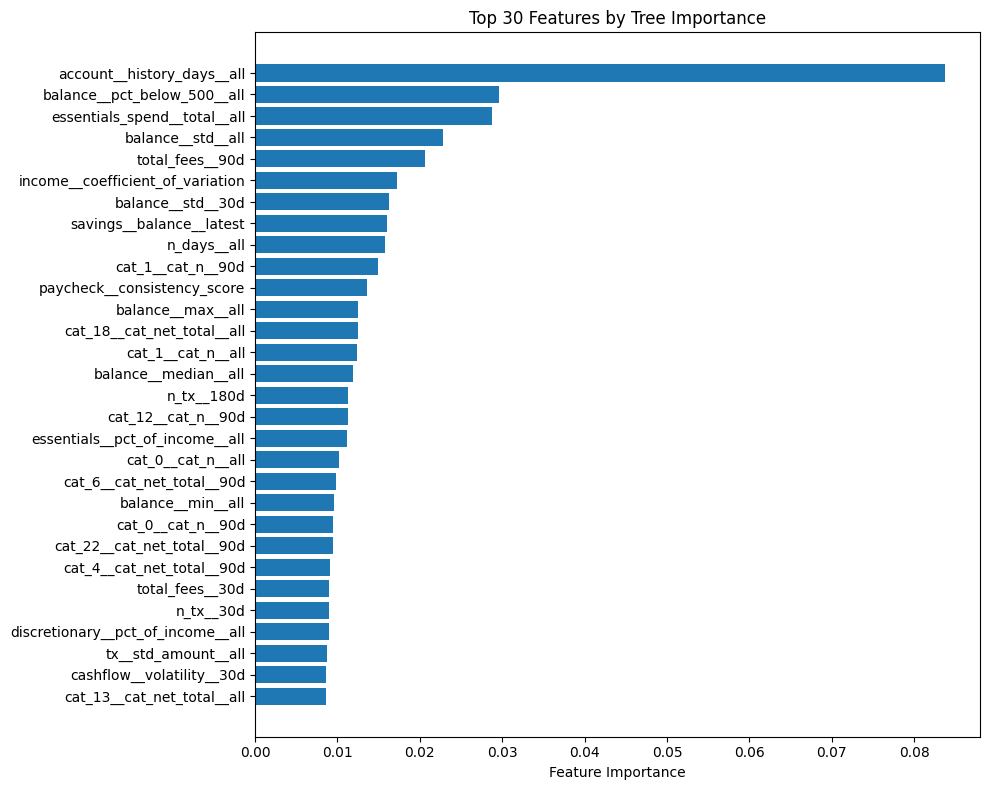

In [24]:
# Get feature importances
importance_df = pd.DataFrame({
    'feature': X_train_s2.columns,
    'importance': model_baseline.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Features by Tree Importance:")
print(importance_df.head(20).to_string())

# Plot top 30
plt.figure(figsize=(10, 8))
top_30 = importance_df.head(30)
plt.barh(range(len(top_30)), top_30['importance'])
plt.yticks(range(len(top_30)), top_30['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 30 Features by Tree Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Stage 5: Permutation Importance

Measure the actual impact on model performance when features are shuffled.

Computing permutation importance (this may take a few minutes)...

Top 20 Features by Permutation Importance:
                          feature  importance_mean  importance_std
7      account__history_days__all         0.043828        0.005761
177      savings__balance__latest         0.017503        0.003253
150  essentials_spend__total__all         0.008619        0.002613
163               total_fees__90d         0.007735        0.001440
127            cat_12__cat_n__90d         0.007671        0.000662
69             cat_12__cat_n__all         0.005790        0.001153
174   paycheck__consistency_score         0.005701        0.001639
5     balance__pct_below_500__all         0.005370        0.003454
14                      n_tx__30d         0.004349        0.000981
0            balance__median__all         0.004332        0.001758
6                     n_days__all         0.003719        0.001594
38     cat_11__cat_net_total__all         0.003212        0.000457
100    cat_13__cat_

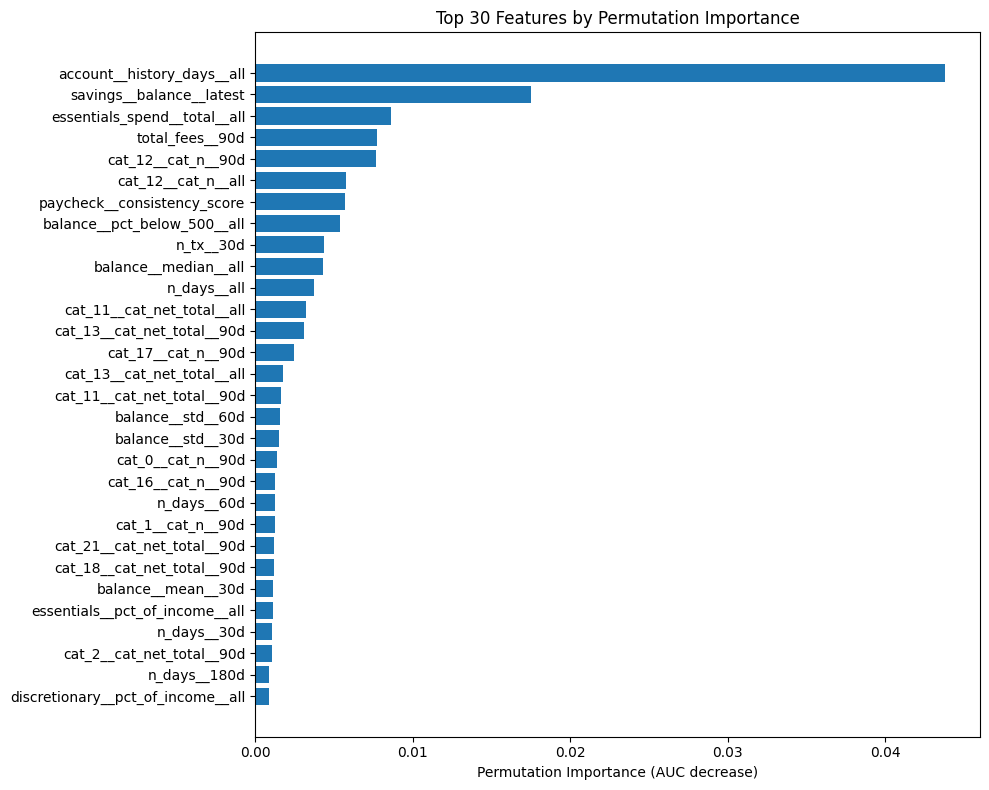

In [25]:
from sklearn.inspection import permutation_importance

print("Computing permutation importance (this may take a few minutes)...")

perm_importance = permutation_importance(
    model_baseline, 
    X_val_s2, 
    y_val,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'feature': X_train_s2.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("\nTop 20 Features by Permutation Importance:")
print(perm_importance_df.head(20).to_string())

# Plot
plt.figure(figsize=(10, 8))
top_30_perm = perm_importance_df.head(30)
plt.barh(range(len(top_30_perm)), top_30_perm['importance_mean'])
plt.yticks(range(len(top_30_perm)), top_30_perm['feature'])
plt.xlabel('Permutation Importance (AUC decrease)')
plt.title('Top 30 Features by Permutation Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Stage 6: SHAP Values

Use SHAP to understand feature contributions and interactions.

Computing SHAP values (this may take several minutes)...

Top 10 Features by SHAP Importance:
                              feature  shap_importance
7          account__history_days__all         0.488845
177          savings__balance__latest         0.373074
150      essentials_spend__total__all         0.165306
5         balance__pct_below_500__all         0.145820
0                balance__median__all         0.109902
171  income__coefficient_of_variation         0.106537
134                cat_20__cat_n__90d         0.095888
163                   total_fees__90d         0.089883
8                  balance__mean__30d         0.089548
174       paycheck__consistency_score         0.080805


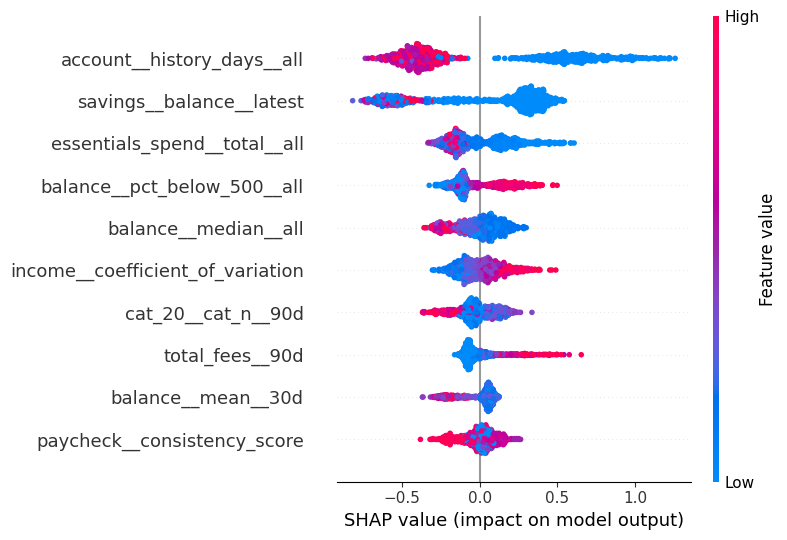

In [26]:
try:
    import shap
    
    print("Computing SHAP values (this may take several minutes)...")
    
    # Sample for faster computation
    sample_size = min(1000, len(X_val_s2))
    X_val_sample = X_val_s2.sample(n=sample_size, random_state=42)
    
    # Create explainer
    explainer = shap.TreeExplainer(model_baseline)
    shap_values = explainer.shap_values(X_val_sample)
    
    # If binary classification, take positive class
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # Calculate mean absolute SHAP values
    shap_importance = pd.DataFrame({
        'feature': X_val_sample.columns,
        'shap_importance': np.abs(shap_values).mean(axis=0)
    }).sort_values('shap_importance', ascending=False)
    
    print("\nTop 10 Features by SHAP Importance:")
    print(shap_importance.head(10).to_string())
        
    # Detailed summary plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_val_sample, max_display=10, show=False)
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("SHAP not installed. Install with: pip install shap")
    shap_importance = None

## Stage 7: Mutual Information

Capture non-linear relationships with the target.

Computing mutual information...

Top 20 Features by Mutual Information:
                                         feature  mi_score
7                     account__history_days__all  0.030201
0                           balance__median__all  0.020910
177                     savings__balance__latest  0.018483
8                             balance__mean__30d  0.018480
28                                  n_days__180d  0.018294
6                                    n_days__all  0.016847
3                              balance__std__all  0.013453
16                             balance__std__60d  0.013377
163                              total_fees__90d  0.012133
5                    balance__pct_below_500__all  0.011687
150                 essentials_spend__total__all  0.011595
178                          savings__n_accounts  0.011551
1                              balance__min__all  0.010940
29                           tx__std_amount__all  0.010234
162                              total_fees

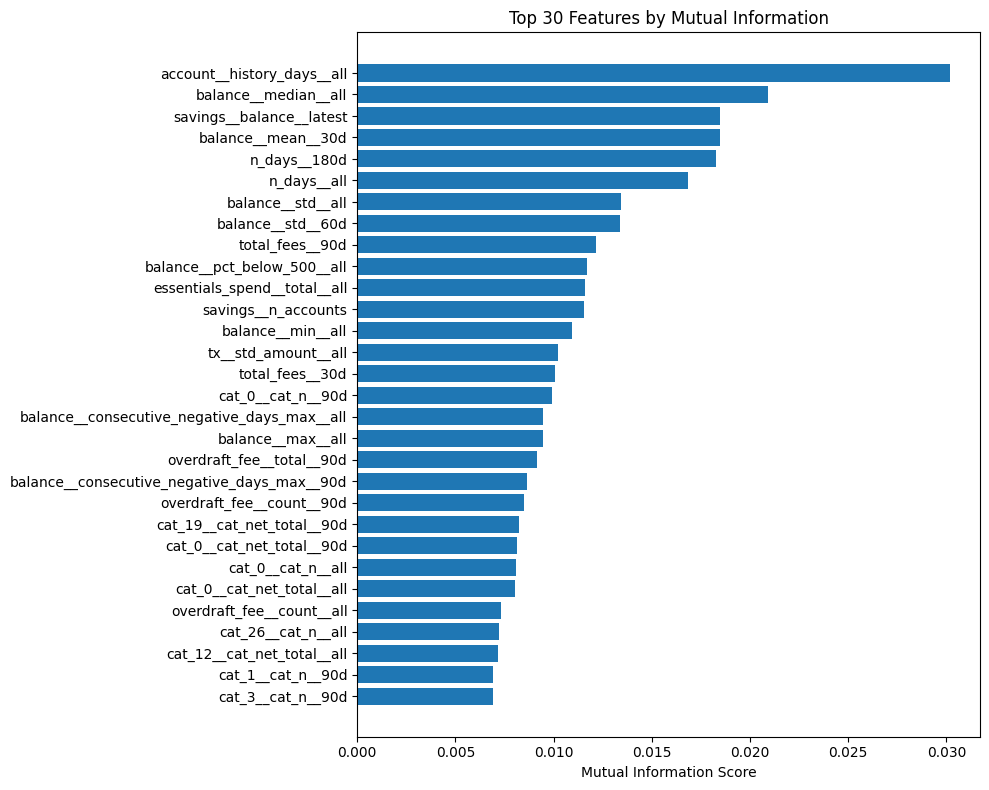

In [27]:
from sklearn.feature_selection import mutual_info_classif

print("Computing mutual information...")

mi_scores = mutual_info_classif(
    X_train_s2, 
    y_train, 
    discrete_features=False,
    random_state=42,
    n_neighbors=5
)

mi_df = pd.DataFrame({
    'feature': X_train_s2.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print("\nTop 20 Features by Mutual Information:")
print(mi_df.head(20).to_string())

# Plot
plt.figure(figsize=(10, 8))
top_30_mi = mi_df.head(30)
plt.barh(range(len(top_30_mi)), top_30_mi['mi_score'])
plt.yticks(range(len(top_30_mi)), top_30_mi['feature'])
plt.xlabel('Mutual Information Score')
plt.title('Top 30 Features by Mutual Information')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Stage 8: Consensus Feature Selection

Combine rankings from all methods to identify the most robust features.

In [28]:
# Normalize all importance scores to 0-1 range
def normalize_scores(df, score_col):
    """Normalize scores to 0-1 range."""
    scores = df[score_col].values
    return (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)

# Combine all rankings
consensus_df = pd.DataFrame({'feature': X_train_s2.columns})

# Add tree importance (normalized)
importance_df_norm = importance_df.copy()
importance_df_norm['tree_score'] = normalize_scores(importance_df_norm, 'importance')
consensus_df = consensus_df.merge(
    importance_df_norm[['feature', 'tree_score']], 
    on='feature', 
    how='left'
)

# Add permutation importance (normalized)
perm_importance_df_norm = perm_importance_df.copy()
perm_importance_df_norm['perm_score'] = normalize_scores(perm_importance_df_norm, 'importance_mean')
consensus_df = consensus_df.merge(
    perm_importance_df_norm[['feature', 'perm_score']], 
    on='feature', 
    how='left'
)

# Add mutual information (normalized)
mi_df_norm = mi_df.copy()
mi_df_norm['mi_score_norm'] = normalize_scores(mi_df_norm, 'mi_score')
consensus_df = consensus_df.merge(
    mi_df_norm[['feature', 'mi_score_norm']], 
    on='feature', 
    how='left'
)

# Add SHAP if available
if shap_importance is not None:
    shap_importance_norm = shap_importance.copy()
    shap_importance_norm['shap_score'] = normalize_scores(shap_importance_norm, 'shap_importance')
    consensus_df = consensus_df.merge(
        shap_importance_norm[['feature', 'shap_score']], 
        on='feature', 
        how='left'
    )
    # Weighted consensus (SHAP gets higher weight)
    consensus_df['consensus_score'] = (
        0.25 * consensus_df['tree_score'].fillna(0) +
        0.30 * consensus_df['perm_score'].fillna(0) +
        0.20 * consensus_df['mi_score_norm'].fillna(0) +
        0.25 * consensus_df['shap_score'].fillna(0)
    )
else:
    # Without SHAP
    consensus_df['consensus_score'] = (
        0.35 * consensus_df['tree_score'].fillna(0) +
        0.40 * consensus_df['perm_score'].fillna(0) +
        0.25 * consensus_df['mi_score_norm'].fillna(0)
    )

consensus_df = consensus_df.sort_values('consensus_score', ascending=False)

print("="*80)
print("TOP 50 FEATURES BY CONSENSUS RANKING")
print("="*80)
print(consensus_df.head(50).to_string())

# Save to CSV
out_path = f"{OUTPUT_PREFIX}feature_importance_consensus.csv"
consensus_df.to_csv(out_path, index=False)
print(f"\n✓ Saved to '{out_path}'")

TOP 50 FEATURES BY CONSENSUS RANKING
                                         feature  tree_score  perm_score  mi_score_norm  shap_score  consensus_score
7                     account__history_days__all    1.000000    1.000000       1.000000    1.000000         1.000000
177                     savings__balance__latest    0.191503    0.427604       0.611995    0.763175         0.489350
150                 essentials_spend__total__all    0.343015    0.234442       0.383936    0.338157         0.317413
5                    balance__pct_below_500__all    0.353745    0.163785       0.386967    0.298296         0.289539
0                           balance__median__all    0.142112    0.141224       0.692347    0.224819         0.272569
163                              total_fees__90d    0.246172    0.215215       0.401739    0.183868         0.252422
6                                    n_days__all    0.188808    0.127893       0.557845    0.145230         0.233446
8                          

## Stage 9: Test Different Feature Set Sizes

Evaluate model performance with different numbers of top features.

Features:  10 | GBM AUC: 0.7744 | LogReg AUC: 0.7532
Features:  20 | GBM AUC: 0.7916 | LogReg AUC: 0.7515
Features:  30 | GBM AUC: 0.7935 | LogReg AUC: 0.7533
Features:  50 | GBM AUC: 0.8004 | LogReg AUC: 0.7538
Features:  75 | GBM AUC: 0.7967 | LogReg AUC: 0.7523
Features: 100 | GBM AUC: 0.8057 | LogReg AUC: 0.7497
Features: 125 | GBM AUC: 0.7938 | LogReg AUC: 0.7502
Features: 150 | GBM AUC: 0.7947 | LogReg AUC: 0.7431
Features: 175 | GBM AUC: 0.7905 | LogReg AUC: 0.7381


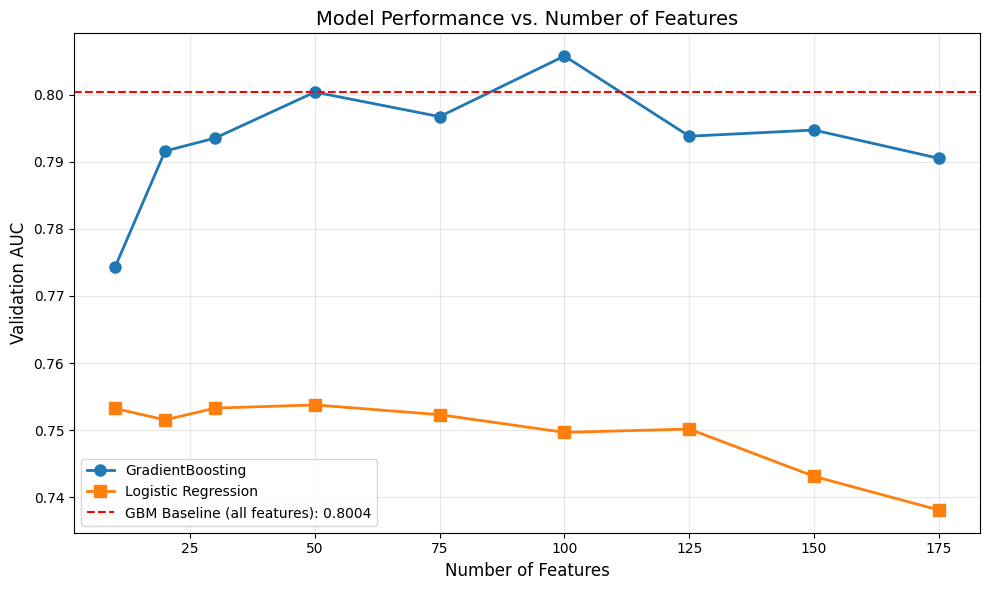


GBM      OPTIMAL: 100 features | AUC = 0.8057
LogReg   OPTIMAL: 50 features  | AUC = 0.7538
GBM Baseline (186 features): 0.8004


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Test different feature counts
feature_counts = [10, 20, 30, 50, 75, 100, 125, 150, 175]
results = []

# Compute class weight for logistic regression
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
lr_class_weight = {0: 1.0, 1: n_neg / n_pos}

for n_features in feature_counts:
    if n_features > len(consensus_df):
        continue
    
    # Select top N features
    top_features = consensus_df.head(n_features)['feature'].tolist()
    
    X_train_subset = X_train_s2[top_features]
    X_val_subset   = X_val_s2[top_features]
    
    # ── GradientBoosting ────────────────────────────────────────
    model_gbm = GradientBoostingClassifier(
        max_depth=6,
        n_estimators=300,
        learning_rate=0.05,
        min_samples_leaf=50,
        random_state=42,
        subsample=0.8
    )
    model_gbm.fit(X_train_subset, y_train)
    auc_gbm = roc_auc_score(y_val, model_gbm.predict_proba(X_val_subset)[:, 1])
    
    # ── Logistic Regression ─────────────────────────────────────
    scaler_sub = StandardScaler()
    X_train_scaled = scaler_sub.fit_transform(X_train_subset)
    X_val_scaled   = scaler_sub.transform(X_val_subset)
    
    model_lr = LogisticRegression(
        solver='saga',
        penalty='l1',
        C=0.1,
        max_iter=2000,
        random_state=42,
        class_weight=lr_class_weight,
    )
    model_lr.fit(X_train_scaled, y_train)
    auc_lr = roc_auc_score(y_val, model_lr.predict_proba(X_val_scaled)[:, 1])
    
    results.append({'n_features': n_features, 'auc_gbm': auc_gbm, 'auc_lr': auc_lr})
    print(f"Features: {n_features:3d} | GBM AUC: {auc_gbm:.4f} | LogReg AUC: {auc_lr:.4f}")

results_df = pd.DataFrame(results)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(results_df['n_features'], results_df['auc_gbm'],
         marker='o', linewidth=2, markersize=8, label='GradientBoosting')
plt.plot(results_df['n_features'], results_df['auc_lr'],
         marker='s', linewidth=2, markersize=8, label='Logistic Regression')
plt.axhline(y=baseline_auc, color='r', linestyle='--',
            label=f'GBM Baseline (all features): {baseline_auc:.4f}')
plt.xlabel('Number of Features', fontsize=12)
plt.ylabel('Validation AUC', fontsize=12)
plt.title('Model Performance vs. Number of Features', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find optimal for each model
best_gbm = results_df.loc[results_df['auc_gbm'].idxmax()]
best_lr  = results_df.loc[results_df['auc_lr'].idxmax()]

print("\n" + "="*80)
print(f"GBM      OPTIMAL: {int(best_gbm['n_features'])} features | AUC = {best_gbm['auc_gbm']:.4f}")
print(f"LogReg   OPTIMAL: {int(best_lr['n_features'])} features  | AUC = {best_lr['auc_lr']:.4f}")
print(f"GBM Baseline ({X_train_s2.shape[1]} features): {baseline_auc:.4f}")
print("="*80)

## Final: Export Ranked Features

✓ Saved to '../output/filtered_ranked_features.txt'
✓ Saved to '../output/filtered_selected_features_top50.txt'

Feature distribution by category (all ranked features):
category
Category                118
Transaction              12
Cashflow                 12
Balance                  10
Overdraft & Fees         10
Multi-Account             9
Low Balance Risk          6
Income & Spending         4
Income Regularity         4
Paycheck-to-Paycheck      1
Name: count, dtype: int64


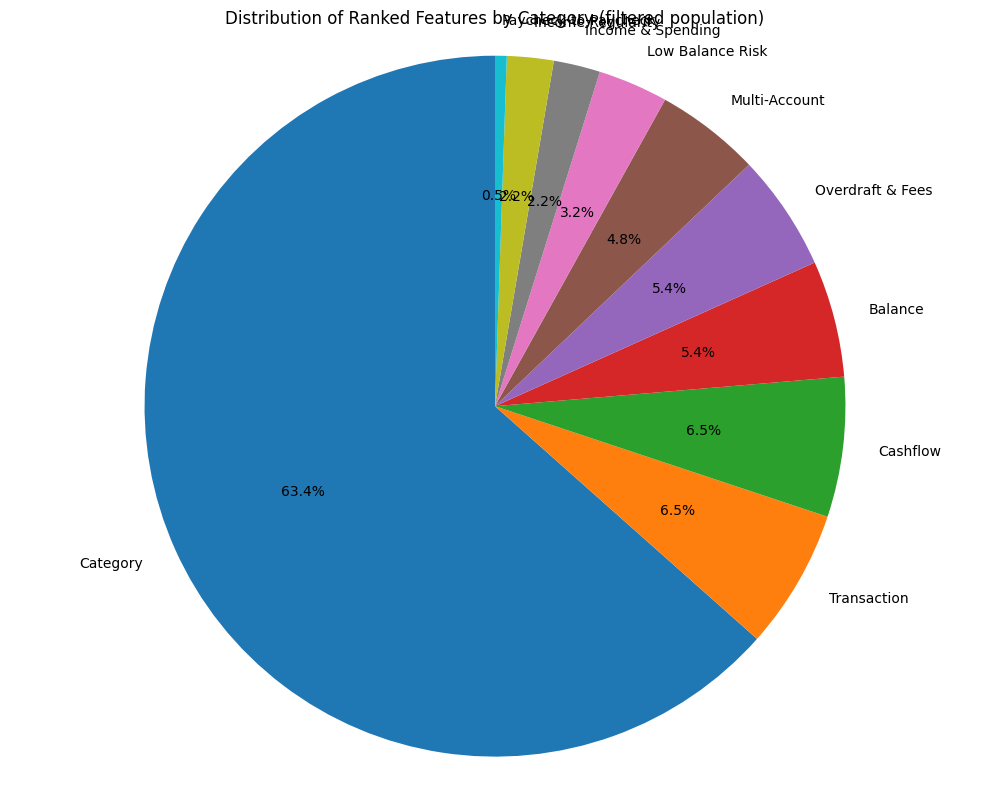

In [30]:
# Export ranked features
final_features = consensus_df['feature'].tolist()

ranked_path = f"{OUTPUT_PREFIX}ranked_features.txt"
top50_path  = f"{OUTPUT_PREFIX}selected_features_top50.txt"

with open(ranked_path, 'w') as f:
    for feat in final_features:
        f.write(feat + '\n')

with open(top50_path, 'w') as f:
    for feat in final_features[:50]:
        f.write(feat + '\n')

print(f"✓ Saved to '{ranked_path}'")
print(f"✓ Saved to '{top50_path}'")

# Create a feature importance visualization by category
ranked_features = consensus_df.copy()

def categorize_feature(feat_name):
    if 'overdraft' in feat_name or 'fee' in feat_name:
        return 'Overdraft & Fees'
    elif any(x in feat_name for x in ['days_below', 'consecutive_negative', 'zero_crossings']):
        return 'Low Balance Risk'
    elif feat_name.startswith('paycheck__') or 'coefficient_of_variation' in feat_name or 'frequency' in feat_name:
        return 'Income Regularity'
    elif 'before_income' in feat_name or 'depletion' in feat_name:
        return 'Paycheck-to-Paycheck'
    elif feat_name.startswith('balance__'):
        return 'Balance'
    elif feat_name.startswith('cashflow__'):
        return 'Cashflow'
    elif feat_name.startswith('cat_'):
        return 'Category'
    elif feat_name.startswith('income__') or 'spend' in feat_name:
        return 'Income & Spending'
    elif any(x in feat_name for x in ['savings__', 'credit_card__', 'revolving_debt__', 'longterm_debt__',
                                       'net_liquid', 'total_debt', 'savings_to_debt']):
        return 'Multi-Account'
    else:
        return 'Transaction'

ranked_features['category'] = ranked_features['feature'].apply(categorize_feature)

category_counts = ranked_features['category'].value_counts()
print("\nFeature distribution by category (all ranked features):")
print(category_counts)

# Pie chart
plt.figure(figsize=(10, 8))
plt.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
plt.title(f'Distribution of Ranked Features by Category ({DATASET} population)')
plt.axis('equal')
plt.tight_layout()
plt.show()

## Summary

This notebook implemented a comprehensive feature selection pipeline:

1. ✅ **Variance Threshold** - Removed near-constant features
2. ✅ **Correlation Filtering** - Removed redundant features (>0.95 correlation)
3. ✅ **Tree-Based Importance** - Gradient boosting built-in importance
4. ✅ **Permutation Importance** - Real impact on predictions
5. ✅ **SHAP Values** - Feature contribution analysis
6. ✅ **Mutual Information** - Non-linear relationships
7. ✅ **Consensus Ranking** - Combined all methods
8. ✅ **Performance Testing** - Validated different feature set sizes

**Key Findings:**
- Started with ~200+ features
- Optimal performance achieved with 50 features
- New risk indicator features (overdraft, low balance, income regularity) are highly predictive
- Final feature list saved for production use